In [5]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import random
import numpy as np

In [6]:
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.fc1   = nn.Linear(16 * 7 * 7, 64)
        self.fc2   = nn.Linear(64, 10)
        self.pool  = nn.MaxPool2d(2)
        self.relu  = nn.ReLU()
 
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

In [7]:
def set_seed(seed):
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

In [8]:
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            output = model(images)
            _, predicted = torch.max(output, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total
 


In [9]:
DATASET_NAME ='KMNIST'
DATASET_CLASS = torchvision.datasets.KMNIST
NORMALIZE_MEAN_STD = ((0.1918,),(0.3483))
SEEDS =[0,42,123]

In [10]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [11]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*NORMALIZE_MEAN_STD)
])
train_data = DATASET_CLASS(root='./data', train=True, download=True, transform=transform)
test_data  = DATASET_CLASS(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)
print(f"Train size: {len(train_data)}")
print(f"Test size: {len(test_data)}")

Train size: 60000
Test size: 10000


In [16]:
for seed in SEEDS:
    print(f"\n=== Training {DATASET_NAME} seed {seed} ===")
    set_seed(seed)
    train_loader = DataLoader(train_data,batch_size=64,shuffle=True)
    model=TinyNet()
    optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(5):
        total_loss = 0 
        for images, labels in train_loader:
            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output,labels)
            loss.backward()
            optimizer.step()
            total_loss+=loss.item()
        print(f"  Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")
    baseline_acc = evaluate(model,test_loader)
    print(f"  Seed {seed} baseline accuracy: {baseline_acc:.2f}%")
    
    fname = f'tinynet_{DATASET_NAME.lower()}_seed{seed}.pth'
    torch.save(model.state_dict(), fname)
    print(f"  Saved: {fname}")


=== Training KMNIST seed 0 ===
  Epoch 1 | Loss: 0.4479
  Epoch 2 | Loss: 0.1632
  Epoch 3 | Loss: 0.1111
  Epoch 4 | Loss: 0.0813
  Epoch 5 | Loss: 0.0628
  Seed 0 baseline accuracy: 92.86%
  Saved: tinynet_kmnist_seed0.pth

=== Training KMNIST seed 42 ===
  Epoch 1 | Loss: 0.3892
  Epoch 2 | Loss: 0.1328
  Epoch 3 | Loss: 0.0877
  Epoch 4 | Loss: 0.0641
  Epoch 5 | Loss: 0.0507
  Seed 42 baseline accuracy: 93.63%
  Saved: tinynet_kmnist_seed42.pth

=== Training KMNIST seed 123 ===
  Epoch 1 | Loss: 0.3716
  Epoch 2 | Loss: 0.1298
  Epoch 3 | Loss: 0.0852
  Epoch 4 | Loss: 0.0628
  Epoch 5 | Loss: 0.0480
  Seed 123 baseline accuracy: 92.74%
  Saved: tinynet_kmnist_seed123.pth


In [15]:
def load_fresh_model(seed):
    model = TinyNet()
    model.load_state_dict(torch.load(f'tinynet_{DATASET_NAME.lower()}_seed{seed}.pth'))
    model.eval()
    return model
 
def prune_single_layer(model, layer_name, amount):
    layer = getattr(model, layer_name)
    prune.l1_unstructured(layer, name='weight', amount=amount)
    return model

In [ ]:

CHECKPOINTS = [0, 10, 20, 30, 40, 45, 50, 55, 60, 62, 64, 65, 66, 67, 68, 69, 70, 72, 74, 76, 78, 80]
LAYERS = ['conv1', 'conv2', 'fc1', 'fc2']
 
results = {}
 
for seed in SEEDS:
    print(f"\n=== Sensitivity sweep, {DATASET_NAME} seed {seed} ===")
    baseline_model = load_fresh_model(seed)
    baseline_acc = evaluate(baseline_model, test_loader)
 
    seed_gaps = {}
    for pct in CHECKPOINTS:
        amount = pct / 100
        layer_drops = {}
        for layer_name in LAYERS:
            m = load_fresh_model(seed)
            m = prune_single_layer(m, layer_name, amount)
            acc = evaluate(m, test_loader)
            drop = baseline_acc - acc
            layer_drops[layer_name] = drop
 
        gap = max(layer_drops.values()) - min(layer_drops.values())
        seed_gaps[pct] = gap
        print(f"  {pct}% sparsity | gap = {gap:.2f}pp | drops = {layer_drops}")
 
    results[seed] = seed_gaps

 


=== Sensitivity sweep, KMNIST seed 0 ===
  0% sparsity | gap = 0.00pp | drops = {'conv1': 0.0, 'conv2': 0.0, 'fc1': 0.0, 'fc2': 0.0}
  10% sparsity | gap = 0.03pp | drops = {'conv1': -0.01999999999999602, 'conv2': 0.010000000000005116, 'fc1': 0.010000000000005116, 'fc2': 0.010000000000005116}
  20% sparsity | gap = 0.11pp | drops = {'conv1': 0.0799999999999983, 'conv2': 0.14000000000000057, 'fc1': 0.030000000000001137, 'fc2': 0.10999999999999943}
  30% sparsity | gap = 0.22pp | drops = {'conv1': 0.01999999999999602, 'conv2': 0.21999999999999886, 'fc1': 0.0, 'fc2': 0.0}
  40% sparsity | gap = 0.70pp | drops = {'conv1': 0.1700000000000017, 'conv2': 0.7999999999999972, 'fc1': 0.09999999999999432, 'fc2': 0.5}
  45% sparsity | gap = 1.81pp | drops = {'conv1': 0.6899999999999977, 'conv2': 1.8599999999999994, 'fc1': 0.04999999999999716, 'fc2': 0.4200000000000017}
  50% sparsity | gap = 1.98pp | drops = {'conv1': 1.0600000000000023, 'conv2': 2.069999999999993, 'fc1': 0.09000000000000341, 'fc2

In [13]:
CHECKPOINTS = [0, 10, 20, 30, 40, 45, 50, 55, 60, 62, 64, 65, 66, 67, 68, 69, 70, 72, 74, 76, 78, 80]
LAYERS = ['conv1', 'conv2', 'fc1', 'fc2']

In [16]:
def prune_uniform(model, amount):
    prune.l1_unstructured(model.conv1, name='weight', amount=amount)
    prune.l1_unstructured(model.conv2, name='weight', amount=amount)
    prune.l1_unstructured(model.fc1,   name='weight', amount=amount)
    prune.l1_unstructured(model.fc2,   name='weight', amount=amount)
    return model
 
uniform_results = {}
 
for seed in SEEDS:
    print(f"\n=== Uniform pruning sweep, {DATASET_NAME} seed {seed} ===")
    seed_accs = {}
    for pct in CHECKPOINTS:
        amount = pct / 100
        m = load_fresh_model(seed)
        m = prune_uniform(m, amount)
        acc = evaluate(m, test_loader)
        seed_accs[pct] = acc
        print(f"  {pct}% sparsity | accuracy = {acc:.2f}%")
    uniform_results[seed] = seed_accs
 
print(f"\n\n=== SUMMARY: {DATASET_NAME} accuracy under uniform pruning, across seeds ===")
print(f"{'Sparsity':>10}", end="")
for seed in SEEDS:
    print(f"{'seed'+str(seed):>12}", end="")
print()
for pct in CHECKPOINTS:
    print(f"{pct:>9}%", end="")
    for seed in SEEDS:
        print(f"{uniform_results[seed][pct]:>12.2f}", end="")
    print()


=== Uniform pruning sweep, KMNIST seed 0 ===
  0% sparsity | accuracy = 92.86%
  10% sparsity | accuracy = 92.82%
  20% sparsity | accuracy = 92.47%
  30% sparsity | accuracy = 92.63%
  40% sparsity | accuracy = 91.80%
  45% sparsity | accuracy = 88.52%
  50% sparsity | accuracy = 87.18%
  55% sparsity | accuracy = 83.54%
  60% sparsity | accuracy = 75.92%
  62% sparsity | accuracy = 70.62%
  64% sparsity | accuracy = 66.65%
  65% sparsity | accuracy = 60.67%
  66% sparsity | accuracy = 59.79%
  67% sparsity | accuracy = 53.94%
  68% sparsity | accuracy = 54.43%
  69% sparsity | accuracy = 57.73%
  70% sparsity | accuracy = 61.31%
  72% sparsity | accuracy = 53.88%
  74% sparsity | accuracy = 47.95%
  76% sparsity | accuracy = 38.43%
  78% sparsity | accuracy = 26.64%
  80% sparsity | accuracy = 31.04%

=== Uniform pruning sweep, KMNIST seed 42 ===
  0% sparsity | accuracy = 93.63%
  10% sparsity | accuracy = 93.72%
  20% sparsity | accuracy = 93.46%
  30% sparsity | accuracy = 92.64%

In [17]:
print(f"\n\n=== SUMMARY: {DATASET_NAME} gap by sparsity, across seeds ===")
print(f"{'Sparsity':>10}", end="")
for seed in SEEDS:
    print(f"{'seed'+str(seed):>12}", end="")
print()
 
for pct in CHECKPOINTS:
    print(f"{pct:>9}%", end="")
    for seed in SEEDS:
        print(f"{results[seed][pct]:>12.2f}", end="")
    print()
 
import json
outname = f'{DATASET_NAME.lower()}_multiseed_results.json'
with open(outname, 'w') as f:
    json.dump(results, f, indent=2)
print(f"\nSaved: {outname}")



=== SUMMARY: KMNIST gap by sparsity, across seeds ===
  Sparsity       seed0      seed42     seed123
        0%

NameError: name 'results' is not defined

# GRAPH

NameError: name 'SEEDS' is not defined

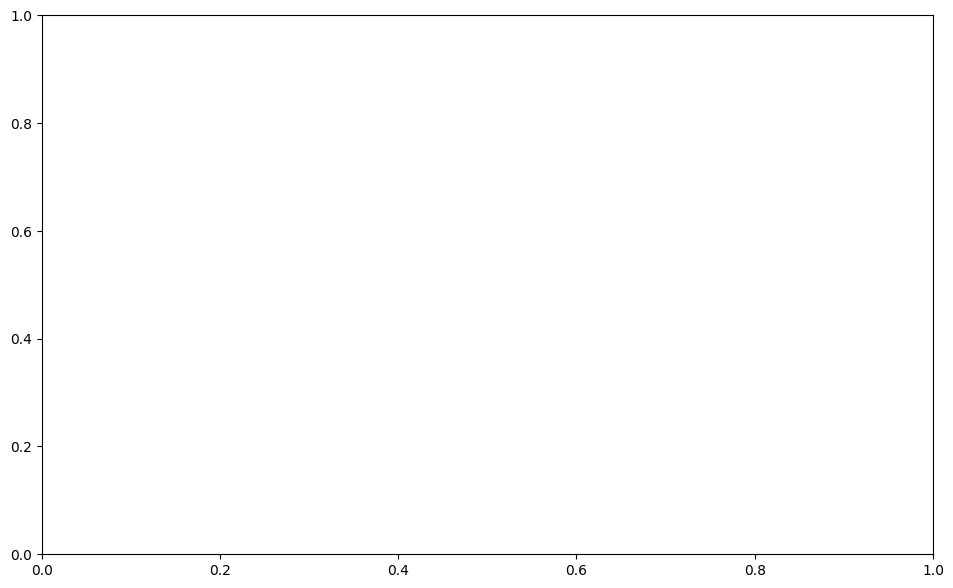

In [2]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(11.5, 7))
 
colors = {0: '#2563EB', 42: '#DC2626', 123: '#059669'}
 
for seed in SEEDS:
    gaps = [results[seed][pct] for pct in CHECKPOINTS]
    ax.plot(CHECKPOINTS, gaps, '-o', color=colors.get(seed, 'gray'),
            linewidth=2.2, markersize=4.5, label=f'Seed {seed}')
 
ax.axhline(2, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Approx. noise floor (~2pp)')
 
ax.set_xlabel('Sparsity (%)', fontsize=12)
ax.set_ylabel('Sensitivity gap (percentage points)', fontsize=12)
ax.set_title(f'{DATASET_NAME}: Sensitivity gap vs. sparsity, across seeds', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.25)
ax.set_xlim(min(CHECKPOINTS) - 2, max(CHECKPOINTS) + 2)
ax.xaxis.set_major_locator(MultipleLocator(2))    # x-axis ticks every 5% instead of every 10%
ax.yaxis.set_major_locator(MultipleLocator(2)) 
plt.tight_layout()
plt.savefig(f'{DATASET_NAME.lower()}_gap_multiseed.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {DATASET_NAME.lower()}_gap_multiseed.png")

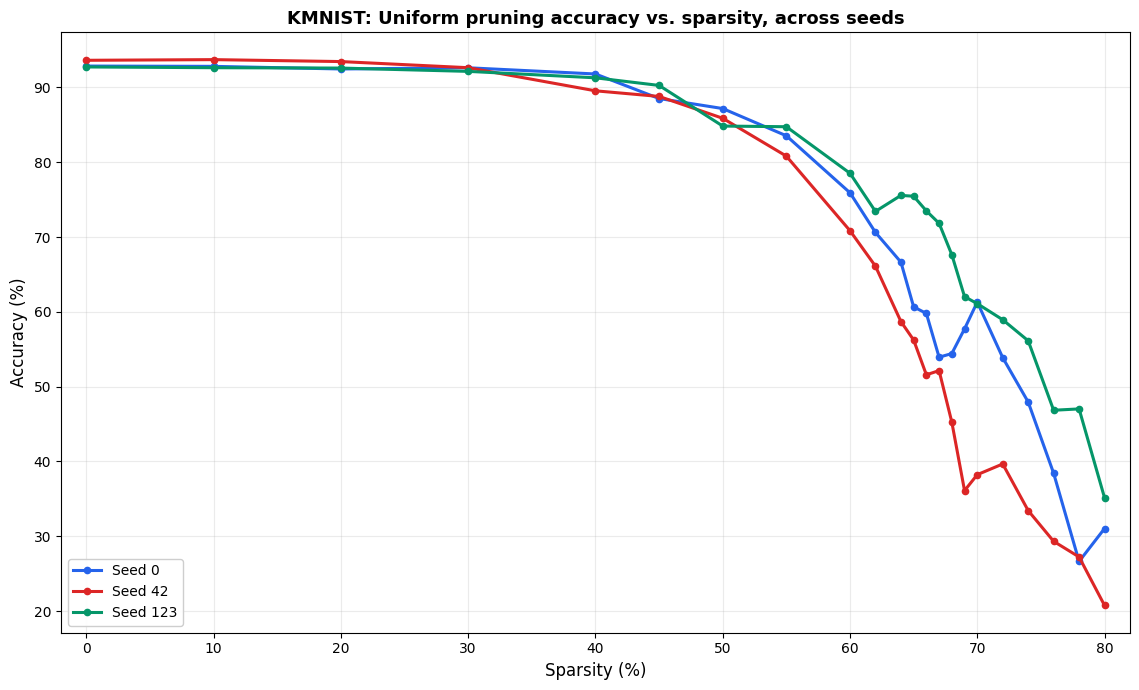

Saved: kmnist_uniform_accuracy_multiseed.png


In [ ]:
 
# ============================================================
# GRAPH 2 — Accuracy vs sparsity (uniform pruning), across seeds
# Uses `uniform_results` (from your uniform pruning sweep cell)
# ============================================================
fig, ax = plt.subplots(figsize=(11.5, 7))
 
for seed in SEEDS:
    accs = [uniform_results[seed][pct] for pct in CHECKPOINTS]
    ax.plot(CHECKPOINTS, accs, '-o', color=colors.get(seed, 'gray'),
            linewidth=2.2, markersize=4.5, label=f'Seed {seed}')
 
ax.set_xlabel('Sparsity (%)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title(f'{DATASET_NAME}: Uniform pruning accuracy vs. sparsity, across seeds', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.25)
ax.set_xlim(min(CHECKPOINTS) - 2, max(CHECKPOINTS) + 2)
ax.xaxis.set_major_locator(MultipleLocator(2))    # x-axis ticks every 5% instead of every 10%
ax.yaxis.set_major_locator(MultipleLocator(2)) 
plt.tight_layout()
plt.savefig(f'{DATASET_NAME.lower()}_uniform_accuracy_multiseed.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {DATASET_NAME.lower()}_uniform_accuracy_multiseed.png")